# Step 1: Architecture and setup

In [55]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [14]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input_data):
        pass

    def backward(self, output_gradient, learning_rate):
        pass

In [15]:
class Conv(Layer):
    def __init__(self, filter_size):
        super().__init__()
        self.filter_size = filter_size
        self.filter = np.random.randn(filter_size, filter_size) * 0.1
        self.bias = 0.0

    def forward(self,input_data):
        self.input = input_data
        input_size = self.input.shape[0]
        output_size = input_size - self.filter_size + 1
        self.output = np.zeros((output_size, output_size))
        for i in range(output_size):
            for j in range(output_size):
                patch = self.input[i:i+self.filter_size, j:j+self.filter_size]
                self.output[i, j] = np.sum(patch * self.filter) + self.bias
        return self.output

    def backward(self, output_gradient, learning_rate):
        filter_gradient = np.zeros(self.filter.shape)
        input_gradient = np.zeros(self.input.shape)
        bias_gradient = np.sum(output_gradient)
        for i in range(output_gradient.shape[0]):
            for j in range(output_gradient.shape[1]):
                patch = self.input[i:i+self.filter_size, j:j+self.filter_size]
                filter_gradient += output_gradient[i, j] * patch
                input_gradient[i:i+self.filter_size, j:j+self.filter_size] += output_gradient[i, j] * self.filter
        self.filter -= learning_rate * filter_gradient
        self.bias -= learning_rate * bias_gradient
        return input_gradient

In [16]:
class ReLU(Layer):
    def __init__(self):
        super().__init__()

    def forward(self,input_data):
        self.input = input_data
        self.output = np.maximum(0, self.input)
        return self.output

    def backward(self, output_gradient, learning_rate):
        return output_gradient * (self.input > 0)

In [17]:
class Max_Pooling(Layer):
    def __init__(self,window_size = 2):
        super().__init__()
        self.window_size = window_size

    def forward(self,input_data):
        self.input = input_data
        out_rows = math.ceil(self.input.shape[0] / self.window_size)
        out_cols = math.ceil(self.input.shape[1] / self.window_size)
        self.output = np.zeros((out_rows, out_cols))
        for i in range(0,self.input.shape[0],self.window_size):
            for j in range(0,self.input.shape[1],self.window_size):
                patch = self.input[i:i+self.window_size,j:j+self.window_size]
                self.output[i//self.window_size,j//self.window_size] = np.max(patch)
        return self.output
    
    def backward(self, output_gradient, learning_rate):
        dx = np.zeros_like(self.input)
        for i in range(0,self.input.shape[0],self.window_size):
            for j in range(0,self.input.shape[1],self.window_size):
                patch = self.input[i:i+self.window_size,j:j+self.window_size]
                max_val = np.max(patch)
                for m in range(patch.shape[0]):
                    for n in range(patch.shape[1]):
                        if patch[m,n] == max_val:
                            dx[i+m,j+n] = output_gradient[i//self.window_size,j//self.window_size]
        return dx

In [18]:
class Reshape(Layer):
    def __init__(self):
        super().__init__()

    def forward(self,input_data):
        self.input = input_data
        self.output = np.reshape(self.input, (-1, 1)) 
        return self.output

    def backward(self, output_gradient, learning_rate):
        return np.reshape(output_gradient, self.input.shape)

In [19]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.weights = np.random.randn(output_size, input_size) * 0.01
        self.bias = np.zeros((output_size, 1))
        
    def forward(self, input_data):
        self.input = input_data
        self.output = np.dot(self.weights, self.input) + self.bias
        return self.output
    
    def backward(self, output_gradient, learning_rate):
        db = output_gradient
        dw = np.dot(output_gradient, self.input.T)
        dx = np.dot(self.weights.T, output_gradient)

        self.weights -= learning_rate * dw
        self.bias -= learning_rate * db

        return dx

In [20]:
class Softmax(Layer):
    def __init__(self):
        super().__init__()

    def forward(self,input_data):
        self.input = input_data
        exps = np.exp(self.input - np.max(self.input))
        self.output = exps / np.sum(exps)
        return self.output

    def backward(self, output_gradient, learning_rate):
        pass

In [21]:
class CrossEntropyLoss:
    def forward(self, predictions, targets):
        self.predictions = predictions
        self.targets = targets
        loss = -np.sum(targets * np.log(predictions + 1e-15))
        return loss

    def backward(self):
        return self.predictions - self.targets

In [25]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train[:1000] / 255.0
y_train_raw = y_train[:1000]

y_train_encoded = np.zeros((len(y_train_raw), 10))
for i, label in enumerate(y_train_raw):
    y_train_encoded[i, label] = 1.0

y_train_encoded = y_train_encoded.reshape(-1, 10, 1)

print(f"Data ready! First image shape: {x_train[0].shape}")
print(f"First label shape: {y_train_encoded[0].shape}")

Data ready! First image shape: (28, 28)
First label shape: (10, 1)


In [26]:
def augment_image(image):
    if np.random.rand() > 0.5:
        return image
    aug_image = np.copy(image)
    shift_x = np.random.randint(-2, 2)
    shift_y = np.random.randint(-2, 2)
    aug_image = np.roll(aug_image, shift_x, axis=0)
    aug_image = np.roll(aug_image, shift_y, axis=1)
    noise = np.random.randn(*aug_image.shape) * 0.05
    aug_image += noise
    aug_image = np.clip(aug_image, 0, 1)
    return aug_image

In [57]:
x_train_split = x_train[:int(0.8 * len(x_train))]
y_train_split = y_train_encoded[:int(0.8 * len(y_train_encoded))]

x_val = x_train[int(0.8 * len(x_train)):len(x_train)]
y_val = y_train_encoded[int(0.8 * len(y_train_encoded)):len(y_train_encoded)]

conv = Conv(filter_size=3)
relu = ReLU()
pool = Max_Pooling(window_size=2)
reshape = Reshape()
dense = Dense(input_size=169, output_size=10)
softmax = Softmax()
loss_func = CrossEntropyLoss()

learning_rate = 0.005
epochs = 10

best_val_accuracy = 0
patience = 2
patience_counter = 0

print("Network initialized. Starting training...")

for epoch in range(epochs):
    total_loss = 0
    correct_predictions = 0
    for step, (x, y_true) in enumerate(zip(x_train, y_train_encoded)):
        x_aug = augment_image(x)
        out = conv.forward(x)
        out = relu.forward(out)
        out = pool.forward(out)
        out = reshape.forward(out)
        out = dense.forward(out)
        predictions = softmax.forward(out)
        loss = loss_func.forward(predictions, y_true)
        total_loss += loss
        if np.argmax(predictions) == np.argmax(y_true):
            correct_predictions += 1
        grad = loss_func.backward() 
        grad = dense.backward(grad, learning_rate)
        grad = reshape.backward(grad, learning_rate)
        grad = pool.backward(grad, learning_rate)
        grad = relu.backward(grad, learning_rate)
        grad = conv.backward(grad, learning_rate)
        
    train_accuracy = (correct_predictions / len(x_train)) * 100
    train_average_loss = total_loss / len(x_train)
    
    val_correct = 0
    
    for x, y_true in zip(x_val, y_val):
        out = conv.forward(x)
        out = relu.forward(out)
        out = pool.forward(out)
        out = reshape.forward(out)
        out = dense.forward(out)
        predictions = softmax.forward(out)
        
        if np.argmax(predictions) == np.argmax(y_true):
            val_correct += 1
            
    val_accuracy = (val_correct / len(x_val)) * 100
    
    print(f"=== Epoch {epoch+1} Complete | Avg Loss: {train_average_loss:.4f} | Accuracy: {train_accuracy:.2f}% ===")
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        patience_counter = 0
        print("    -> Validation improved! Saving model...")
    else:
        patience_counter += 1
        print(f"    -> No improvement. Patience: {patience_counter}/{patience}")
        
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered, The network stopped learning at Epoch {epoch+1}.")
            break 

    learning_rate *= 0.9

Network initialized. Starting training...
=== Epoch 1 Complete | Avg Loss: 2.0589 | Accuracy: 31.60% ===
    -> Validation improved! Saving model...
=== Epoch 2 Complete | Avg Loss: 1.0213 | Accuracy: 64.20% ===
    -> Validation improved! Saving model...
=== Epoch 3 Complete | Avg Loss: 0.8103 | Accuracy: 73.90% ===
    -> Validation improved! Saving model...
=== Epoch 4 Complete | Avg Loss: 0.7144 | Accuracy: 76.20% ===
    -> Validation improved! Saving model...
=== Epoch 5 Complete | Avg Loss: 0.6525 | Accuracy: 78.20% ===
    -> Validation improved! Saving model...
=== Epoch 6 Complete | Avg Loss: 0.6072 | Accuracy: 80.30% ===
    -> Validation improved! Saving model...
=== Epoch 7 Complete | Avg Loss: 0.5720 | Accuracy: 81.70% ===
    -> Validation improved! Saving model...
=== Epoch 8 Complete | Avg Loss: 0.5436 | Accuracy: 82.70% ===
    -> No improvement. Patience: 1/2
=== Epoch 9 Complete | Avg Loss: 0.5198 | Accuracy: 83.80% ===
    -> Validation improved! Saving model...
==

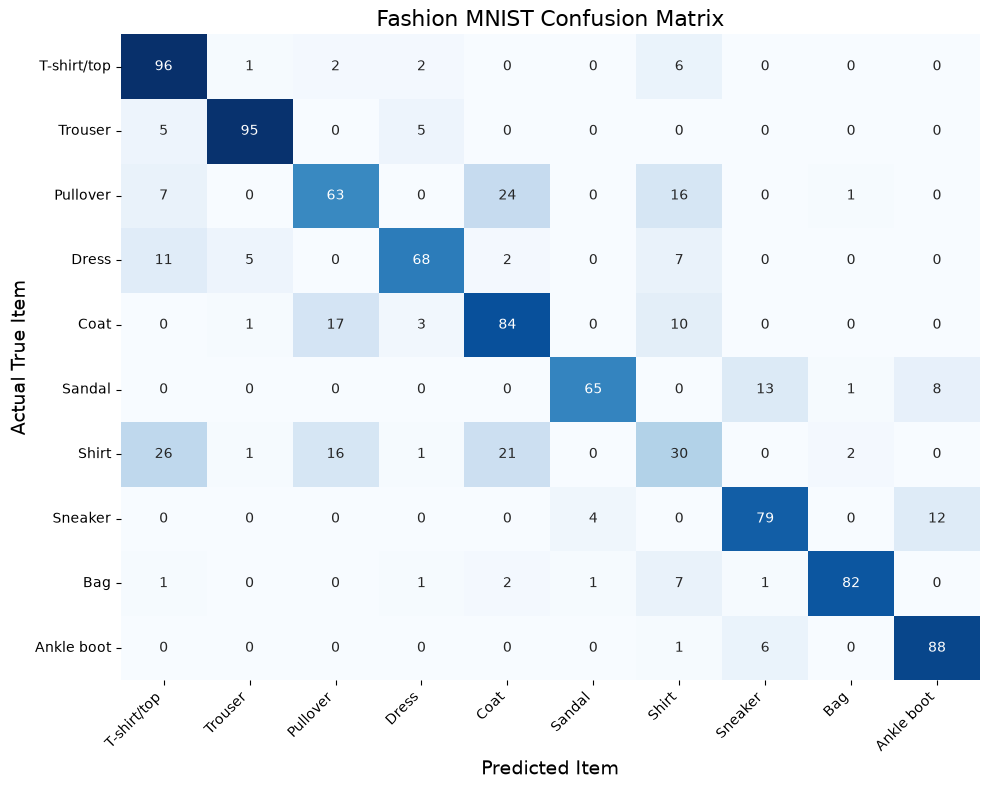

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

all_predictions = []
all_true_labels = []

for x, y_true in zip(x_test[:1000] / 255.0, y_test[:1000]):
    out = conv.forward(x)
    out = relu.forward(out)
    out = pool.forward(out)
    out = reshape.forward(out)
    out = dense.forward(out)
    predictions = softmax.forward(out)
    all_predictions.append(np.argmax(predictions))
    all_true_labels.append(y_true)

cm = confusion_matrix(all_true_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=class_names, yticklabels=class_names)
plt.title("Fashion MNIST Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Item", fontsize=14)
plt.ylabel("Actual True Item", fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

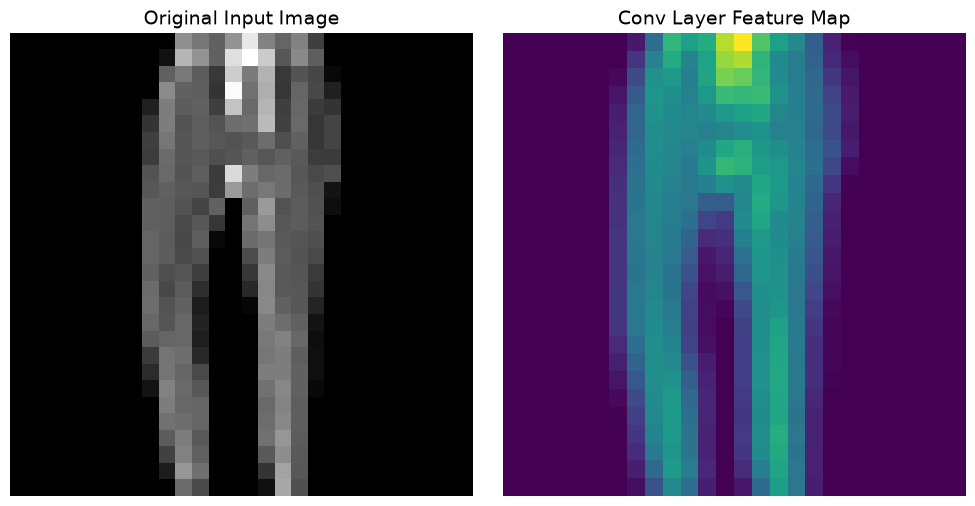

In [54]:
random_number = np.random.randint(0, 1000)
sample_image = x_test[random_number] / 255.0 

feature_map = conv.forward(sample_image)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(sample_image, cmap='gray')
axes[0].set_title("Original Input Image", fontsize=14)
axes[0].axis('off')

axes[1].imshow(feature_map, cmap='viridis')
axes[1].set_title("Conv Layer Feature Map", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()